# **Directed percolation in Rust-Python**

Demo simulation of directed percolation on a 1d lattice.

<hr>

## Preliminaries

In [15]:
from essentials import *
dprs.__version__

'2026.4.12'

<hr>

## Parameters

In [29]:
expts = {
    0:  dict(p_1=0.001, p_2=0.999,  p_3=0, scale=1.3),
    1:  dict(p_1=0.2682, p_2=0.9,     p_3=0, scale=1.03),
    2:  dict(p_1=0.45155, p_2=0.8,     p_3=0, scale=0.955),
    3:  dict(p_1=0.5855, p_2=0.7,     p_3=0, scale=0.935),
    4:  dict(p_1=0.64475, p_2=0.64475, p_3=0, scale=0.94),
    5:  dict(p_1=0.68705, p_2=0.6,     p_3=0, scale=0.935),
    6:  dict(p_1=0.76714, p_2=0.5,     p_3=0, scale=0.95),
    7:  dict(p_1=0.83180, p_2=0.4,     p_3=0, scale=0.975),
    8:  dict(p_1=0.88505, p_2=0.3,     p_3=0, scale=1.01),
    9:  dict(p_1=0.92961, p_2=0.2,     p_3=0, scale=1.072),
    10: dict(p_1=0.96748, p_2=0.1,     p_3=0, scale=1.2),
    11: dict(p_1=0.999, p_2=0.001,     p_3=0, scale=1.3),
}
expt = expts[2]
expt

{'p_1': 0.45155, 'p_2': 0.8, 'p_3': 0, 'scale': 0.955}

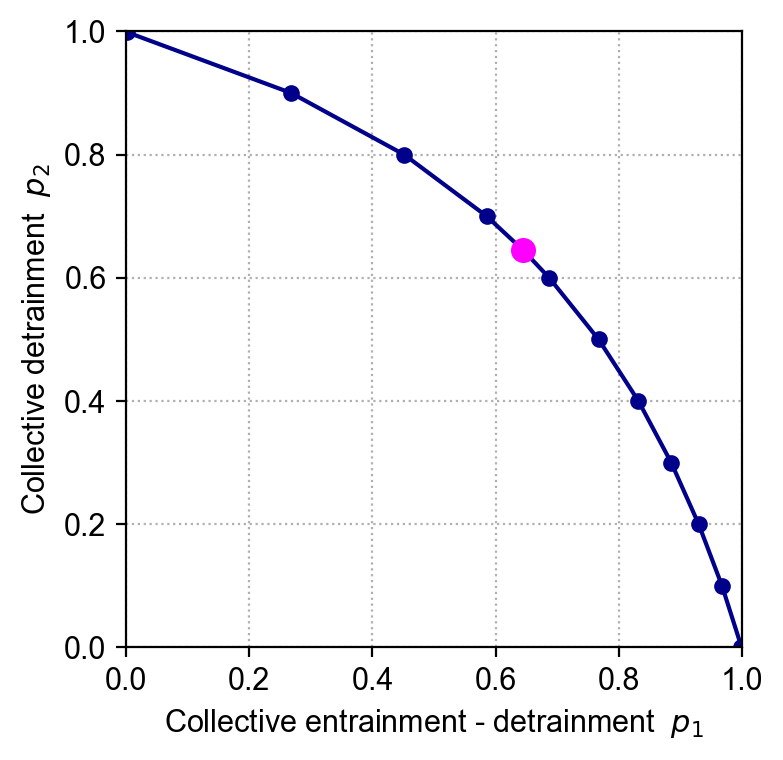

In [17]:
p1_p2 = np.array([ (expt["p_1"], expt["p_2"]) for (key, expt,) in expts.items()]).T
plt.figure(figsize=(4, 4,),)
plt.plot(*p1_p2, "-o", ms=5, color="DarkBlue",)
plt.plot(expts[4]["p_1"], expts[4]["p_2"], "o", ms=8, color="magenta",)
plt.xlim(0, 1,)
plt.ylim(0, 1,)
plt.xlabel(r"Collective entrainment - detrainment  $p_1$")
plt.ylabel(r"Collective detrainment  $p_2$")
axes = plt.gca()
axes.set_aspect(1)
plt.grid(ls=":")

In [18]:
class Parameters:
    growth_model = GrowthModel.Bedload
    dim = Dimension.D1
    n_x: int = 1_000_000
    n_y: int = 1
    n_z: int = 1
    p_1: float = expt["p_1"]
    p_2: float = expt["p_2"]
    p_3: float = expt["p_3"]
    n_iterations: int = 3000
    sample_period: int = 1
    initial_condition = InitialCondition.Randomized
    p_initial: float = 0.99
    random_seed: int = 1
    topology_x = Topology.Periodic
    topology_y = Topology.Unspecified
    topology_z = Topology.Unspecified
    bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_y = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bcs_z = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_y = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    bc_values_z = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    do_edge_buffering: bool = True
    processing = Processing.Parallel
    n_threads: int = 16
parameters = Parameters()

<hr>

## Simulation

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [19]:
n_raw_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float

In [20]:
(n_raw_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)

In [21]:
print(f"Total number of lattice time slices = {n_raw_lattices}\n")

Total number of lattice time slices = 3001



<hr>

## Post-processing

The function `sim.dk` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all of them concatenated into one long 1d list.

In [22]:
n_lattices: int
lattices: NDArray
tracking: NDArray
(n_lattices, lattices, tracking) \
    = postprocessing(parameters, n_raw_lattices, raw_lattices, raw_tracking,)
lattices.shape

(1000000, 3001)

<hr>

## Visualization

### Prep

In [23]:
viz = Viz(dpi=125)
name: str

In [24]:
image_lattice_history = partial(
    viz.image_lattice_history,
    lattices=lattices, 
    p=parameters, 
    x=min(parameters.n_x, 500),
    t=min(n_lattices, 501),
    fig_size=(6, 4,),
)

### Evolution

lattice_p0p451550_s1_nx1000000


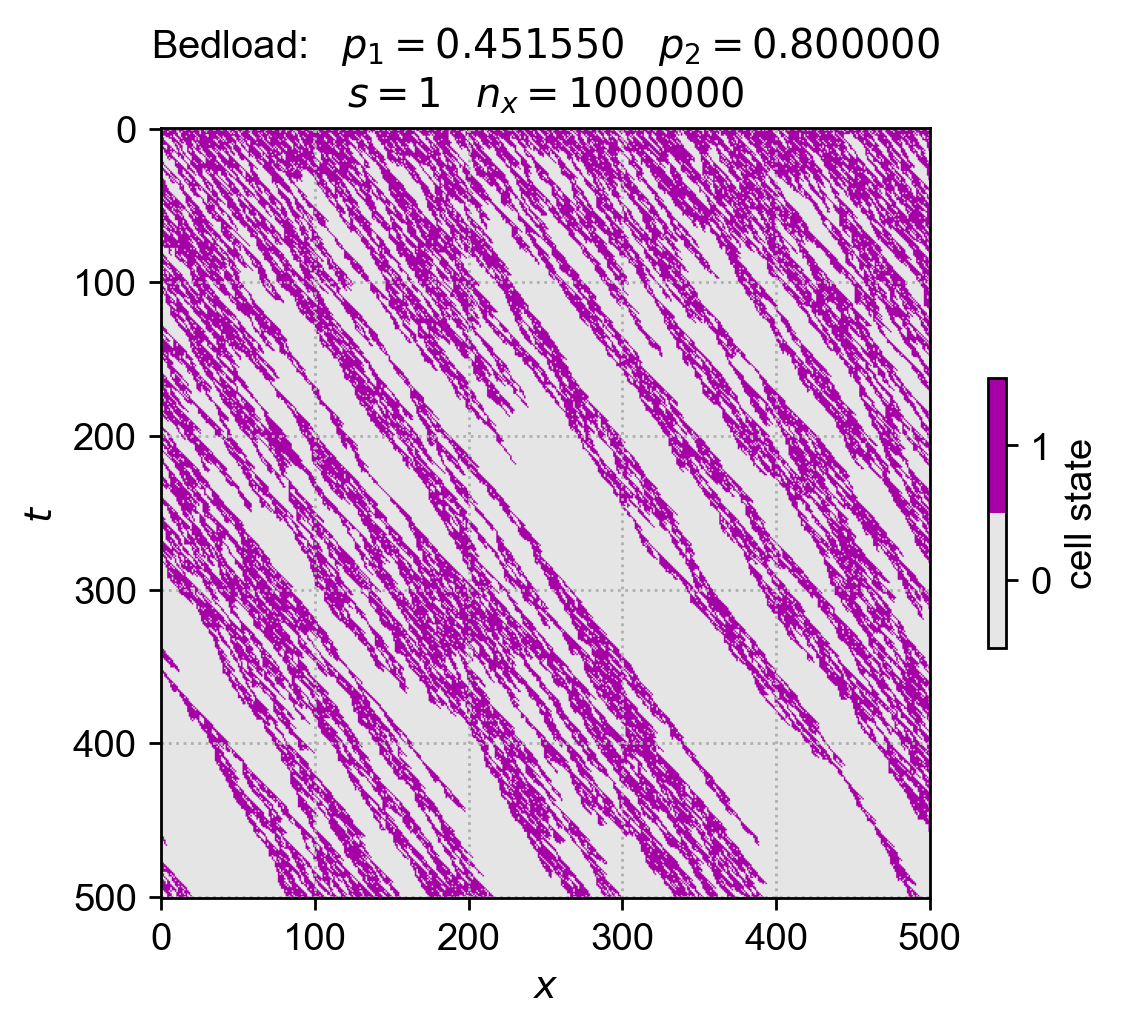

In [25]:
if n_lattices>0:
    i_slice = 0
    name = make_name(parameters, "lattice",)
    print(name)
    image_lattice_history(
        name=name, title=make_title(parameters), 
    )
    plt.show()

### Mean order parameter $t$-decay

See Henkel et al (2008), tables 4.1 and 4.3: the mean order parameter (mean occupancy) $\overline\rho$ should decay with time as
$$
    \rho(t) \sim t^{-\delta}
$$
where in $d=1$ we should find $\delta \approx 0.1594646$. 

ρmean_p0p451550_s1_nx1000000


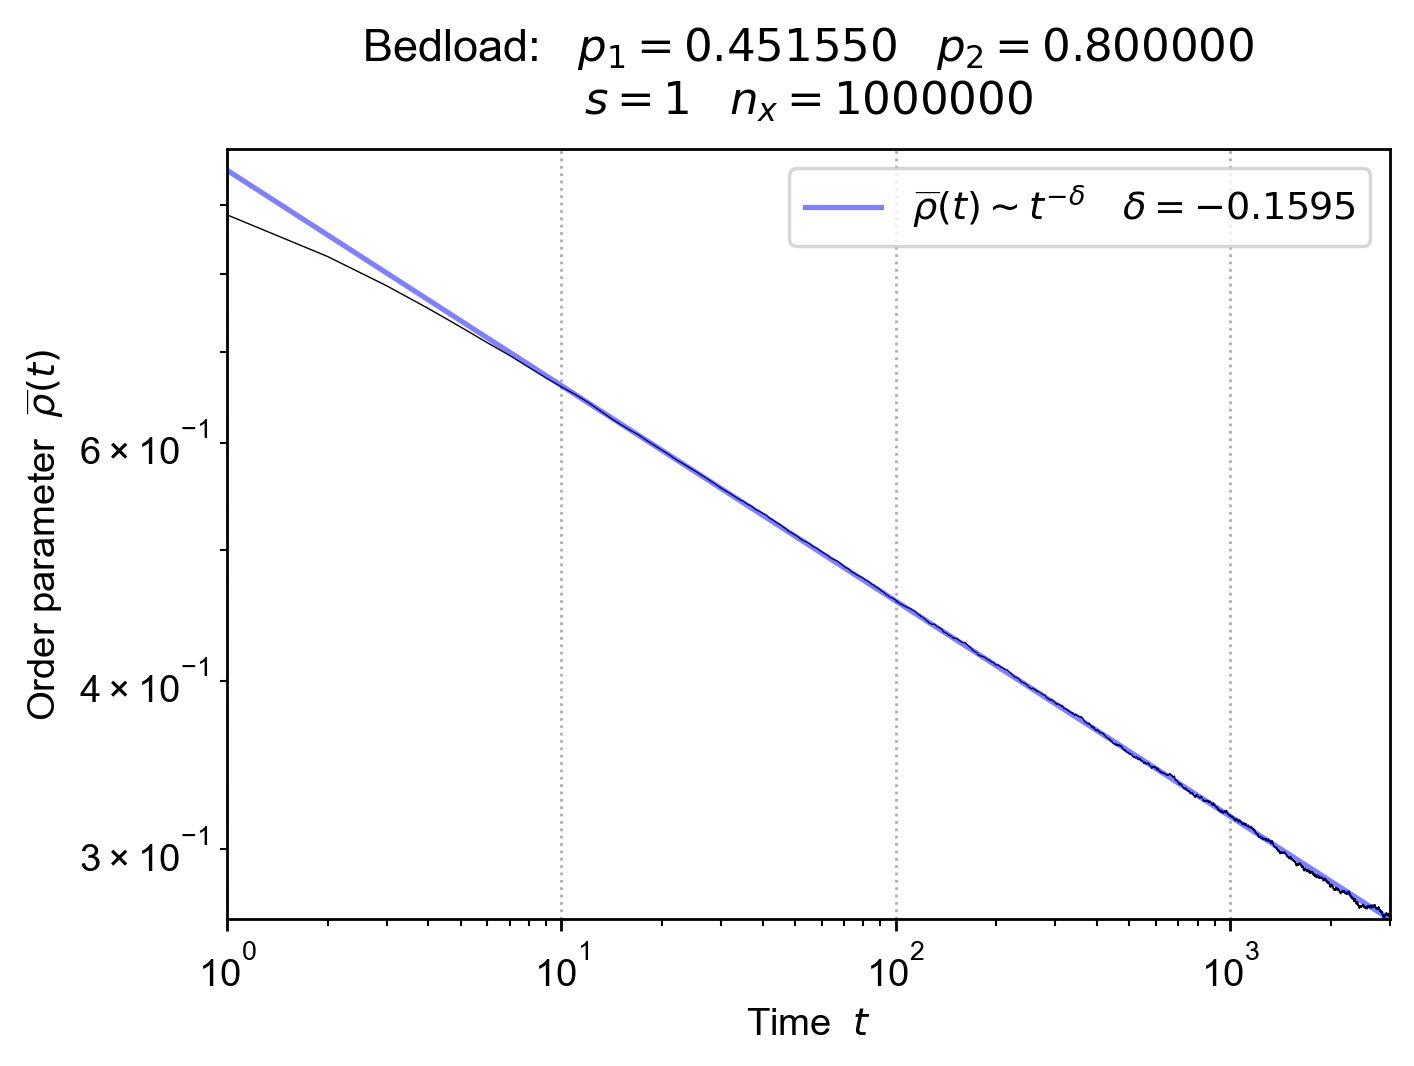

In [30]:
δ = 0.1594646
scale = expt["scale"]
        
name = make_name(parameters, "ρmean", None, )
print(name)
viz.plot_lattice_statistic(
    name,
    make_title(parameters, None),
    tracking,
    choices=("time", "ρ_mean"),
    labels=(
        "Order parameter  $\\widebar{\\rho}(t)$", 
        "$\\widebar{\\rho}(t) \\sim t^{-\\delta}$",
        "${\\delta}$",
    ),
    exponent=-δ, 
    scale=scale,
    i_offset=0,
    do_ref_curve=True,
)
plt.show()

In [27]:
i_offset: int = parameters.n_iterations//50
t: NDArray = tracking["time"][i_offset:]
ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
(exponent, scale, r_value, p_value, std_err) \
    = linregress(np.log(t), np.log(ρ_mean))
print(f"t range: {t[0]}-{t[-1]}")
print(rf"Estimated t-decay exponent:  δ = {exponent:0.3f}")

t range: 60.0-3000.0
Estimated t-decay exponent:  δ = -0.161


<hr>

## Export

In [28]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "bedload1d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/bedload1d'